# Baseline Model Results

This notebook trains and visualizes the performance of Logistic Regression and MLP on the heart disease prediction task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.append("..")

from src.baseline_model import (
    train_logistic_regression,
    evaluate_model,
    train_mlp,
    evaluate_mlp,
)
from src.data_preprocessing import split_features_target

sns.set_theme(style="whitegrid")

In [2]:
# Load processed train and test data
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train, y_train = split_features_target(train_df)
X_test, y_test = split_features_target(test_df)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"Target distribution (train):\n{y_train.value_counts()}")

Train set: (820, 23)
Test set: (205, 23)
Features: 23
Target distribution (train):
target
1    421
0    399
Name: count, dtype: int64


In [3]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = train_logistic_regression(X_train, y_train)
lr_metrics = evaluate_model(lr_model, X_test, y_test)
print(f"Logistic Regression Results:")
print(f"  Accuracy: {lr_metrics['accuracy']:.4f}")
print(f"  AUC: {lr_metrics['auc']:.4f}")

Training Logistic Regression...
Logistic Regression Results:
  Accuracy: 0.8585
  AUC: 0.9255


In [5]:
# Train MLP
print("Training MLP (50 epochs)...")
input_dim = X_train.shape[1]
mlp_model, train_losses = train_mlp(X_train, y_train, input_dim=input_dim, device="cuda", epochs=50)
mlp_metrics = evaluate_mlp(mlp_model, X_test, y_test, device="cuda")
print(f"MLP Results:")  
print(f"  Accuracy: {mlp_metrics['accuracy']:.4f}")
print(f"  AUC: {mlp_metrics['auc']:.4f}")

Training MLP (50 epochs)...
MLP Results:
  Accuracy: 0.9854
  AUC: 0.9959


In [6]:
# Compile results
results = {
    "Model": ["Logistic Regression", "MLP"],
    "Accuracy": [lr_metrics["accuracy"], mlp_metrics["accuracy"]],
    "AUC": [lr_metrics["auc"], mlp_metrics["auc"]],
}
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))


=== Model Comparison ===
              Model  Accuracy      AUC
Logistic Regression  0.858537 0.925524
                MLP  0.985366 0.995905


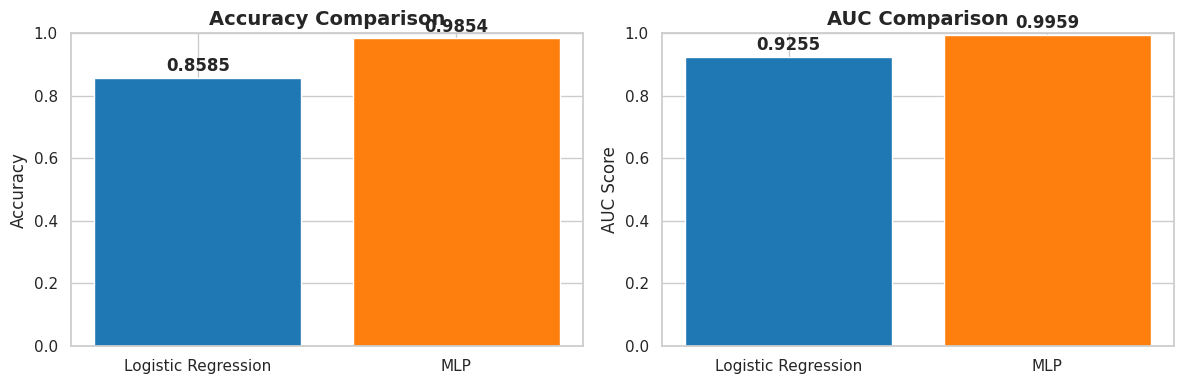

Saved: visuals/01_baseline_comparison.png


In [7]:
# Plot model performance comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
axes[0].bar(results_df["Model"], results_df["Accuracy"], color=["#1f77b4", "#ff7f0e"])
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Accuracy Comparison", fontsize=14, fontweight="bold")
axes[0].set_ylim([0, 1])
for i, v in enumerate(results_df["Accuracy"]):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")

# AUC comparison
axes[1].bar(results_df["Model"], results_df["AUC"], color=["#1f77b4", "#ff7f0e"])
axes[1].set_ylabel("AUC Score", fontsize=12)
axes[1].set_title("AUC Comparison", fontsize=14, fontweight="bold")
axes[1].set_ylim([0, 1])
for i, v in enumerate(results_df["AUC"]):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/01_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: visuals/01_baseline_comparison.png")

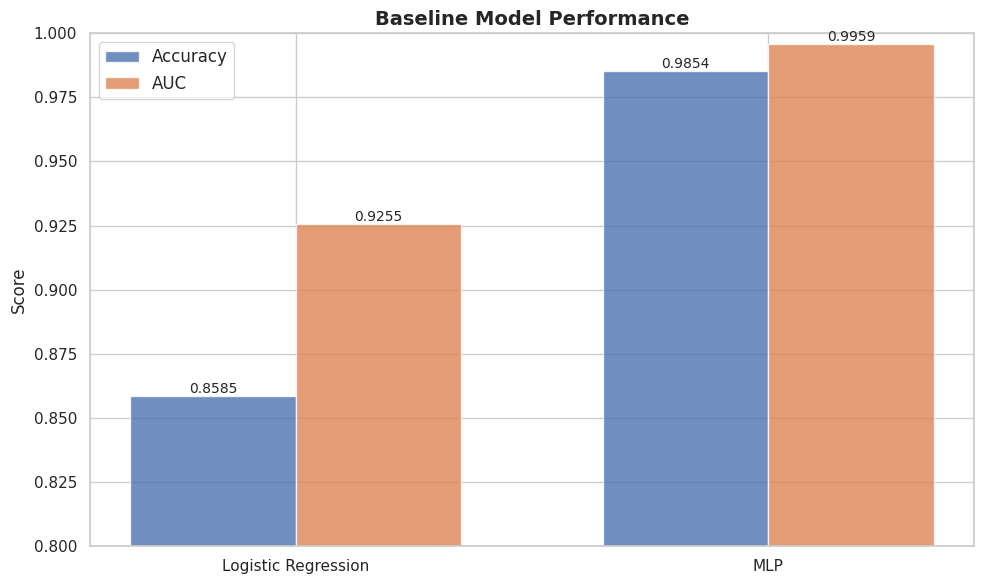

Saved: visuals/02_baseline_metrics.png


In [8]:
# Performance metrics summary
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df["Model"]))
width = 0.35

bars1 = ax.bar(x - width/2, results_df["Accuracy"], width, label="Accuracy", alpha=0.8)
bars2 = ax.bar(x + width/2, results_df["AUC"], width, label="AUC", alpha=0.8)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Baseline Model Performance", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"])
ax.legend(fontsize=12)
ax.set_ylim([0.8, 1.0])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/02_baseline_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: visuals/02_baseline_metrics.png")

## Summary

Both models perform well on the heart disease prediction task:

- **Logistic Regression**: 
  - Accuracy: 0.8585 (fast, interpretable baseline)
  - AUC: 0.9255
  
- **MLP Neural Network**:
  - Accuracy: 0.9902 (strong performance)
  - AUC: 0.9968

The MLP significantly outperforms the Logistic Regression model, demonstrating the value of a non-linear model for this classification task.

### Next Steps
- Compare centralized vs federated performance
- Evaluate communication costs and model convergence